This notebook uses a 80/10/10 split along with a window size of 500 and a steps size of 100 and as the model uses a CNN  followed by a bidirectional LSTM with attention.

Here we normalize the dataset using the global mean and standard deviation

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
from collections import Counter

# Global Configuration Parameters
WINDOW_SIZE = 500
STEP_SIZE = 100
BATCH_SIZE = 128
NUM_CLASSES = 10
TEST_SIZE = 0.10
VAL_SIZE = 0.10
RANDOM_STATE = 42
EPOCHS = 40

LABELED_DIR = Path("./filtered/csv_labeled").resolve()

In [5]:
from pathlib import Path
import numpy as np
import pandas as pd
from collections import Counter

# 1. Correct Relative Paths: Go UP one level (..) to sEMG-dataset, then into the specific folders
LABELED_DIR = Path("../filtered/csv_labeled").resolve()
PROCESSED_DIR = Path("../processed_data").resolve()

def load_subject_dependent_split(
    labeled_dir: Path,
    window_size=500,
    step_size=100,
    test_size=0.10, 
    val_size=0.10,  
    random_state=42,
):
    all_files = sorted(labeled_dir.glob("*.csv"))
    if not all_files:
        raise FileNotFoundError(f"No CSV files found in {labeled_dir}")

    X_all, y_all = [], []

    for file_path in all_files:
        print(f"Processing subject file: {file_path.name}")
        df = pd.read_csv(file_path, header=None)
        data = df.values

        num_windows = (len(data) - window_size) // step_size + 1
        for i in range(num_windows):
            start = i * step_size
            end = start + window_size

            window_labels = data[start:end, 4]
            if len(np.unique(window_labels)) != 1:
                continue

            X_all.append(data[start:end, 0:4].astype(np.float32))
            y_all.append(int(data[start, 4]))

    X_all = np.array(X_all, dtype=np.float32)
    y_all = np.array(y_all, dtype=np.int64)

    if X_all.size == 0:
        raise ValueError("No windows were extracted from the labeled CSV files.")

    print("\nRaw unique labels:", np.unique(y_all))
    if y_all.min() == 1:
        print("Labels are 1-indexed! Shifting to 0-indexed...")
        y_all -= 1
    print("Corrected unique labels:", np.unique(y_all))

    rng = np.random.default_rng(random_state)
    indices = rng.permutation(len(X_all))
    X_all = X_all[indices]
    y_all = y_all[indices]

    n_total = len(X_all)
    n_test = int(n_total * test_size)
    n_val = int(n_total * val_size)
    n_train = n_total - n_val - n_test 

    X_train = X_all[:n_train]
    y_train = y_all[:n_train]
    X_val = X_all[n_train:n_train + n_val]
    y_val = y_all[n_train:n_train + n_val]
    X_test = X_all[n_train + n_val:]
    y_test = y_all[n_train + n_val:]

    global_mean = X_train.mean(axis=(0, 1), keepdims=True)
    global_std = X_train.std(axis=(0, 1), keepdims=True)
    global_std[global_std == 0] = 1e-8

    X_train = (X_train - global_mean) / global_std
    X_val = (X_val - global_mean) / global_std
    X_test = (X_test - global_mean) / global_std

    print("\n--- Subject-Dependent Split Summary ---")
    print(f"X_train shape : {X_train.shape}")
    print(f"X_val shape   : {X_val.shape}")
    print(f"X_test shape  : {X_test.shape}")
    print(f"Train class dist : {dict(sorted(Counter(y_train.tolist()).items()))}")
    print(f"Val class dist   : {dict(sorted(Counter(y_val.tolist()).items()))}")
    print(f"Test class dist  : {dict(sorted(Counter(y_test.tolist()).items()))}")

    return X_train, y_train, X_val, y_val, X_test, y_test


# 2. Load and process the dataset 
X_train, y_train, X_val, y_val, X_test, y_test = load_subject_dependent_split(
    LABELED_DIR, 
    window_size=500, 
    step_size=100, 
    test_size=0.10, 
    val_size=0.10, 
    random_state=42
)

# 3. Save the processed data 
print("\n--- Saving Processed Data to Disk ---")
PROCESSED_DIR.mkdir(parents=True, exist_ok=True) 
save_path = PROCESSED_DIR / "sd_emg_data_normalized.npz"

np.savez_compressed(
    save_path,
    X_train=X_train, y_train=y_train,
    X_val=X_val, y_val=y_val,
    X_test=X_test, y_test=y_test
)

print(f"✅ Data successfully packed and saved to: {save_path}")
print(f"💾 File size on disk: {save_path.stat().st_size / (1024 * 1024):.2f} MB")

Processing subject file: 10_filtered.csv
Processing subject file: 11_filtered.csv
Processing subject file: 12_filtered.csv
Processing subject file: 13_filtered.csv
Processing subject file: 14_filtered.csv
Processing subject file: 15_filtered.csv
Processing subject file: 16_filtered.csv
Processing subject file: 17_filtered.csv
Processing subject file: 18_filtered.csv
Processing subject file: 19_filtered.csv
Processing subject file: 1_filtered.csv
Processing subject file: 20_filtered.csv
Processing subject file: 21_filtered.csv
Processing subject file: 22_filtered.csv
Processing subject file: 23_filtered.csv
Processing subject file: 24_filtered.csv
Processing subject file: 25_filtered.csv
Processing subject file: 26_filtered.csv
Processing subject file: 27_filtered.csv
Processing subject file: 28_filtered.csv
Processing subject file: 29_filtered.csv
Processing subject file: 2_filtered.csv
Processing subject file: 30_filtered.csv
Processing subject file: 31_filtered.csv
Processing subject

In [3]:
import numpy as np
from pathlib import Path

# Define the exact path using the double-dot to step up one directory
PROCESSED_DIR = Path("../processed_data").resolve()
load_path = PROCESSED_DIR / "sd_emg_data_normalized.npz"

print(f"Loading compressed data from: {load_path} ...")

# 1. Load the archive
data = np.load(load_path)

# 2. Unpack the arrays back into their respective variables
X_train = data['X_train']
y_train = data['y_train']
X_val   = data['X_val']
y_val   = data['y_val']
X_test  = data['X_test']
y_test  = data['y_test']

print("\n✅ Data successfully loaded into memory!")
print("--- Sanity Check ---")
print(f"X_train shape : {X_train.shape}")
print(f"X_val shape   : {X_val.shape}")
print(f"X_test shape  : {X_test.shape}")

Loading compressed data from: D:\EMG\EMG_Large\sEMG-dataset\processed_data\sd_emg_data_normalized.npz ...

✅ Data successfully loaded into memory!
--- Sanity Check ---
X_train shape : (403200, 500, 4)
X_val shape   : (50400, 500, 4)
X_test shape  : (50400, 500, 4)


In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from tqdm import tqdm

# Convert arrays into PyTorch datasets
train_dataset = TensorDataset(torch.tensor(X_train), torch.tensor(y_train))
val_dataset = TensorDataset(torch.tensor(X_val), torch.tensor(y_val))
test_dataset = TensorDataset(torch.tensor(X_test), torch.tensor(y_test))

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f"Train batches: {len(train_loader)} | Val batches: {len(val_loader)} | Test batches: {len(test_loader)}")

# Class-balanced loss
counts = np.bincount(y_train)
weights = 1.0 / counts.astype(np.float32)
weights = weights / weights.sum() * NUM_CLASSES
class_weights = torch.FloatTensor(weights)
criterion = nn.CrossEntropyLoss(weight=class_weights.to(torch.device('cuda' if torch.cuda.is_available() else 'cpu')))

# Training device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")




Train batches: 3150 | Val batches: 394 | Test batches: 394
Using device: cuda


In [5]:
class CNNBiLSTMAttention(nn.Module):
    def __init__(self, input_dim=4, hidden_dim=64, num_classes=10):
        super(CNNBiLSTMAttention, self).__init__()
        self.cnn = nn.Sequential(
            nn.Conv1d(in_channels=4, out_channels=32, kernel_size=7, padding=3),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),
            nn.Conv1d(in_channels=32, out_channels=64, kernel_size=5, padding=2),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),
            nn.Conv1d(in_channels=64, out_channels=128, kernel_size=3, padding=1),
            nn.BatchNorm1d(128),
            nn.ReLU()
        )
        self.lstm = nn.LSTM(
            input_size=128,
            hidden_size=hidden_dim,
            num_layers=2,
            bidirectional=True,
            batch_first=True,
            dropout=0.3
        )
        self.attention_linear = nn.Linear(hidden_dim * 2, hidden_dim * 2)
        self.attention_query = nn.Linear(hidden_dim * 2, 1, bias=False)
        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim * 2, 128),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = x.permute(0, 2, 1)
        x = self.cnn(x)
        x = x.permute(0, 2, 1)
        lstm_out, _ = self.lstm(x)
        energy = torch.tanh(self.attention_linear(lstm_out))
        attention_scores = self.attention_query(energy)
        attention_weights = F.softmax(attention_scores, dim=1)
        context_vector = torch.sum(attention_weights * lstm_out, dim=1)
        return self.classifier(context_vector)

# Build model and verify output shape
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CNNBiLSTMAttention(input_dim=4, hidden_dim=64, num_classes=NUM_CLASSES).to(device)
print(model)
dummy = torch.randn(8, 500, 4).to(device)
out = model(dummy)
print(f"Output shape: {out.shape}")

CNNBiLSTMAttention(
  (cnn): Sequential(
    (0): Conv1d(4, 32, kernel_size=(7,), stride=(1,), padding=(3,))
    (1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv1d(32, 64, kernel_size=(5,), stride=(1,), padding=(2,))
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv1d(64, 128, kernel_size=(3,), stride=(1,), padding=(1,))
    (9): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
  )
  (lstm): LSTM(128, 64, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
  (attention_linear): Linear(in_features=128, out_features=128, bias=True)
  (attention_query): Linear(in_features=128, out_features=1, bias=False)
  (classifier): Sequential

In [6]:
# Optimizer and scheduler

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', patience=3, factor=0.5, verbose=True
)


c:\Users\Asus\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\optim\lr_scheduler.py:28: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn("The verbose parameter is deprecated. Please use get_last_lr() "


In [7]:
def check_pred_distribution(model, loader, device, label=""):
    model.eval()
    all_preds = []
    with torch.no_grad():
        for batch_X, _ in loader:
            preds = model(batch_X.to(device)).argmax(dim=1).cpu().numpy()
            all_preds.extend(preds.tolist())
    print(f"  [{label}] Pred dist: {dict(sorted(Counter(all_preds).items()))}")



In [ ]:
MODEL_SAVE_PATH = "../best_sd_bilstm_emg.pth"

EARLY_STOP_PATIENCE = 10
best_val_acc = 0.0
patience_counter = 0
for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    train_bar = tqdm(train_loader, desc=f"Epoch {epoch+1:02d}/{EPOCHS} [Train]", unit="batch")
    for batch_X, batch_y in train_bar:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        optimizer.zero_grad()
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        running_loss += loss.item() * batch_X.size(0)
        _, predicted = torch.max(outputs, 1)
        total_train += batch_y.size(0)
        correct_train += (predicted == batch_y).sum().item()

        train_bar.set_postfix({
            "loss": f"{loss.item():.4f}",
            "acc": f"{(predicted == batch_y).sum().item() / batch_y.size(0) * 100:.2f}%",
            "lr": f"{optimizer.param_groups[0]['lr']:.6f}"
        })

    epoch_train_loss = running_loss / len(train_loader.dataset)
    epoch_train_acc = (correct_train / total_train) * 100

    model.eval()
    val_loss = 0.0
    correct_val = 0
    total_val = 0
    val_bar = tqdm(val_loader, desc=f"Epoch {epoch+1:02d}/{EPOCHS} [Val  ]", unit="batch", leave=False)
    with torch.no_grad():
        for batch_X, batch_y in val_bar:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)
            val_loss += loss.item() * batch_X.size(0)
            _, predicted = torch.max(outputs, 1)
            total_val += batch_y.size(0)
            correct_val += (predicted == batch_y).sum().item()
            val_bar.set_postfix({"loss": f"{loss.item():.4f}"})

    epoch_val_loss = val_loss / len(val_loader.dataset)
    epoch_val_acc = (correct_val / total_val) * 100
    scheduler.step(epoch_val_acc)

    print(f"Summary -> Train Loss: {epoch_train_loss:.4f} | Train Acc: {epoch_train_acc:.2f}% | Val Loss: {epoch_val_loss:.4f} | Val Acc: {epoch_val_acc:.2f}% | LR: {optimizer.param_groups[0]['lr']:.6f}")

    if (epoch + 1) % 5 == 0:
        print("  Diagnostics:")
        check_pred_distribution(model, train_loader, device, "Train")
        check_pred_distribution(model, val_loader, device, "Val  ")

    if epoch_val_acc > best_val_acc:
        best_val_acc = epoch_val_acc
        patience_counter = 0
        torch.save(model.state_dict(), MODEL_SAVE_PATH)
        print(f"--> ✅ Saved best model! Val Acc: {best_val_acc:.2f}%")
    else:
        patience_counter += 1
        print(f"    No improvement. Patience: {patience_counter}/{EARLY_STOP_PATIENCE}")

    if patience_counter >= EARLY_STOP_PATIENCE:
        print(f"\n⛔ Early stopping at epoch {epoch+1}!")
        break

    print("-" * 80)

model.load_state_dict(torch.load(MODEL_SAVE_PATH))
print(f"\n✅ Training complete! Best Val Acc: {best_val_acc:.2f}%")

Epoch 01/40 [Train]: 100%|██████████| 3150/3150 [01:36<00:00, 32.69batch/s, loss=1.8130, acc=32.81%, lr=0.001000]


Summary -> Train Loss: 1.8542 | Train Acc: 26.55% | Val Loss: 1.7858 | Val Acc: 28.41% | LR: 0.001000
--> ✅ Saved best model! Val Acc: 28.41%
--------------------------------------------------------------------------------


Epoch 02/40 [Train]: 100%|██████████| 3150/3150 [01:18<00:00, 40.19batch/s, loss=1.6358, acc=28.91%, lr=0.001000]


Summary -> Train Loss: 1.7317 | Train Acc: 29.97% | Val Loss: 1.6846 | Val Acc: 31.80% | LR: 0.001000
--> ✅ Saved best model! Val Acc: 31.80%
--------------------------------------------------------------------------------


Epoch 03/40 [Train]: 100%|██████████| 3150/3150 [01:20<00:00, 39.08batch/s, loss=1.7026, acc=32.81%, lr=0.001000]


...

Summary -> Train Loss: 1.1815 | Train Acc: 51.04% | Val Loss: 1.1698 | Val Acc: 51.71% | LR: 0.000250
    No improvement. Patience: 1/10
--------------------------------------------------------------------------------


Epoch 39/40 [Train]: 100%|██████████| 3150/3150 [01:21<00:00, 38.48batch/s, loss=1.2157, acc=53.12%, lr=0.000250]


Summary -> Train Loss: 1.1783 | Train Acc: 51.24% | Val Loss: 1.2051 | Val Acc: 50.68% | LR: 0.000250
    No improvement. Patience: 2/10
--------------------------------------------------------------------------------


Epoch 40/40 [Train]: 100%|██████████| 3150/3150 [01:22<00:00, 38.40batch/s, loss=1.1869, acc=50.78%, lr=0.000250]


Summary -> Train Loss: 1.1762 | Train Acc: 51.46% | Val Loss: 1.1402 | Val Acc: 52.74% | LR: 0.000250
  Diagnostics:
  [Train] Pred dist: {0: 45337, 1: 34542, 2: 50934, 3: 35253, 4: 32684, 5: 41281, 6: 42374, 7: 40763, 8: 36582, 9: 43450}
  [Val  ] Pred dist: {0: 5775, 1: 4365, 2: 6311, 3: 4466, 4: 4025, 5: 5110, 6: 5291, 7: 5136, 8: 4568, 9: 5353}
    No improvement. Patience: 3/10
--------------------------------------------------------------------------------

✅ Training complete! Best Val Acc: 52.75%


In [ ]:
import torch
import torch.nn as nn
from tqdm import tqdm
from collections import Counter

MODEL_SAVE_PATH = "../best_sd_bilstm_emg.pth"

# 1. Load the optimal weights from the first 40 epochs
print("Loading pre-trained weights from disk...")
model.load_state_dict(torch.load(MODEL_SAVE_PATH))
model.to(device)

# 2. Re-initialize Optimizer and Scheduler
# Using an even smaller LR (1e-4) since we are in deep fine-tuning for Phase 3!
optimizer = torch.optim.Adam(model.parameters(), lr=0.00025, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', patience=3, factor=0.5, verbose=True
)

# 3. Continuation Setup
ADDITIONAL_EPOCHS = 40
EARLY_STOP_PATIENCE = 10
patience_counter = 0

print("\n--- Running Baseline Evaluation ---")
# Establish the 50-epoch baseline so we don't accidentally save a worse model
model.eval()
correct_baseline = 0
total_baseline = 0
with torch.no_grad():
    for batch_X, batch_y in val_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        outputs = model(batch_X)
        _, predicted = torch.max(outputs, 1)
        total_baseline += batch_y.size(0)
        correct_baseline += (predicted == batch_y).sum().item()

best_val_acc = (correct_baseline / total_baseline) * 100
print(f"Baseline Validation Accuracy locked at: {best_val_acc:.2f}%")
print("Starting additional 40 epochs (Phase 3)...\n")
print("-" * 80)

# 4. The Phase 3 Training Loop
for epoch in range(ADDITIONAL_EPOCHS):
    # --- TRAINING ---
    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    # Label the epoch visually as 51-80
    display_epoch = epoch + 41 
    train_bar = tqdm(train_loader, desc=f"Epoch {display_epoch:02d}/{40 + ADDITIONAL_EPOCHS} [Train]", unit="batch")
    
    for batch_X, batch_y in train_bar:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        optimizer.zero_grad()
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        running_loss += loss.item() * batch_X.size(0)
        _, predicted = torch.max(outputs, 1)
        total_train += batch_y.size(0)
        correct_train += (predicted == batch_y).sum().item()

        train_bar.set_postfix({
            "loss": f"{loss.item():.4f}",
            "acc": f"{(predicted == batch_y).sum().item() / batch_y.size(0) * 100:.2f}%",
            "lr": f"{optimizer.param_groups[0]['lr']:.6f}"
        })

    epoch_train_loss = running_loss / len(train_loader.dataset)
    epoch_train_acc = (correct_train / total_train) * 100

    # --- VALIDATION ---
    model.eval()
    val_loss = 0.0
    correct_val = 0
    total_val = 0
    val_bar = tqdm(val_loader, desc=f"Epoch {display_epoch:02d}/{40 + ADDITIONAL_EPOCHS} [Val  ]", unit="batch", leave=False)
    
    with torch.no_grad():
        for batch_X, batch_y in val_bar:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)
            val_loss += loss.item() * batch_X.size(0)
            _, predicted = torch.max(outputs, 1)
            total_val += batch_y.size(0)
            correct_val += (predicted == batch_y).sum().item()
            val_bar.set_postfix({"loss": f"{loss.item():.4f}"})

    epoch_val_loss = val_loss / len(val_loader.dataset)
    epoch_val_acc = (correct_val / total_val) * 100
    
    # Step the learning rate scheduler based on validation accuracy
    scheduler.step(epoch_val_acc)

    print(f"Summary -> Train Loss: {epoch_train_loss:.4f} | Train Acc: {epoch_train_acc:.2f}% | Val Loss: {epoch_val_loss:.4f} | Val Acc: {epoch_val_acc:.2f}% | LR: {optimizer.param_groups[0]['lr']:.6f}")

    # Diagnostics every 5 epochs
    if (epoch + 1) % 5 == 0:
        print("  Diagnostics:")
        check_pred_distribution(model, train_loader, device, "Train")
        check_pred_distribution(model, val_loader, device, "Val  ")

    # --- CHECKPOINTING ---
    if epoch_val_acc > best_val_acc:
        best_val_acc = epoch_val_acc
        patience_counter = 0
        torch.save(model.state_dict(), MODEL_SAVE_PATH)
        print(f"--> ✅ Saved NEW best model! Val Acc: {best_val_acc:.2f}%")
    else:
        patience_counter += 1
        print(f"    No improvement. Patience: {patience_counter}/{EARLY_STOP_PATIENCE}")

    """ if patience_counter >= EARLY_STOP_PATIENCE:
        print(f"\n⛔ Early stopping triggered at actual epoch {display_epoch}!")
        break """

    print("-" * 80)

# Final Reload
model.load_state_dict(torch.load(MODEL_SAVE_PATH))
print(f"\n✅ Phase 3 Training complete! Ultimate Best Val Acc: {best_val_acc:.2f}%")

Loading pre-trained weights from disk...

--- Running Baseline Evaluation ---
Baseline Validation Accuracy locked at: 51.23%
Starting additional 40 epochs (Phase 3)...

--------------------------------------------------------------------------------


Epoch 41/80 [Train]: 100%|██████████| 3150/3150 [01:19<00:00, 39.81batch/s, loss=1.2001, acc=47.66%, lr=0.000250]


Summary -> Train Loss: 1.2629 | Train Acc: 47.53% | Val Loss: 1.2051 | Val Acc: 50.18% | LR: 0.000250
    No improvement. Patience: 1/10
--------------------------------------------------------------------------------


Epoch 42/80 [Train]: 100%|██████████| 3150/3150 [01:18<00:00, 39.99batch/s, loss=1.2099, acc=51.56%, lr=0.000250]


Summary -> Train Loss: 1.2556 | Train Acc: 47.85% | Val Loss: 1.2244 | Val Acc: 49.34% | LR: 0.000250
    No improvement. Patience: 2/10
--------------------------------------------------------------------------------


...

Summary -> Train Loss: 1.1305 | Train Acc: 53.34% | Val Loss: 1.0836 | Val Acc: 54.98% | LR: 0.000031
    No improvement. Patience: 2/10
--------------------------------------------------------------------------------


Epoch 79/80 [Train]: 100%|██████████| 3150/3150 [01:22<00:00, 38.28batch/s, loss=1.0828, acc=56.25%, lr=0.000031]


Summary -> Train Loss: 1.1305 | Train Acc: 53.42% | Val Loss: 1.1096 | Val Acc: 54.02% | LR: 0.000031
    No improvement. Patience: 3/10
--------------------------------------------------------------------------------


Epoch 80/80 [Train]: 100%|██████████| 3150/3150 [01:22<00:00, 38.07batch/s, loss=0.9800, acc=63.28%, lr=0.000031]


Summary -> Train Loss: 1.1317 | Train Acc: 53.42% | Val Loss: 1.1010 | Val Acc: 54.49% | LR: 0.000016
  Diagnostics:
  [Train] Pred dist: {0: 45100, 1: 41487, 2: 42771, 3: 33184, 4: 43999, 5: 37227, 6: 43421, 7: 39470, 8: 39152, 9: 37389}
  [Val  ] Pred dist: {0: 5640, 1: 5185, 2: 5385, 3: 4198, 4: 5438, 5: 4688, 6: 5290, 7: 5049, 8: 4901, 9: 4626}
    No improvement. Patience: 4/10
--------------------------------------------------------------------------------

✅ Phase 3 Training complete! Ultimate Best Val Acc: 55.12%


In [14]:
# Load the best weights verified by your validation split
model.load_state_dict(torch.load("best_sd_bilstm_emg.pth"))
model.eval()

correct_test = 0
total_test = 0

with torch.no_grad():
    for batch_X, batch_y in test_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        outputs = model(batch_X)
        _, predicted = torch.max(outputs, 1)
        total_test += batch_y.size(0)
        correct_test += (predicted == batch_y).sum().item()

final_test_acc = (correct_test / total_test) * 100
print("====================================================")
print(f"FINAL SUB-INDEPENDENT ACCURACY ON TEST SUBJECTS: {final_test_acc:.2f}%")
print("====================================================")

FINAL SUB-INDEPENDENT ACCURACY ON TEST SUBJECTS: 54.74%


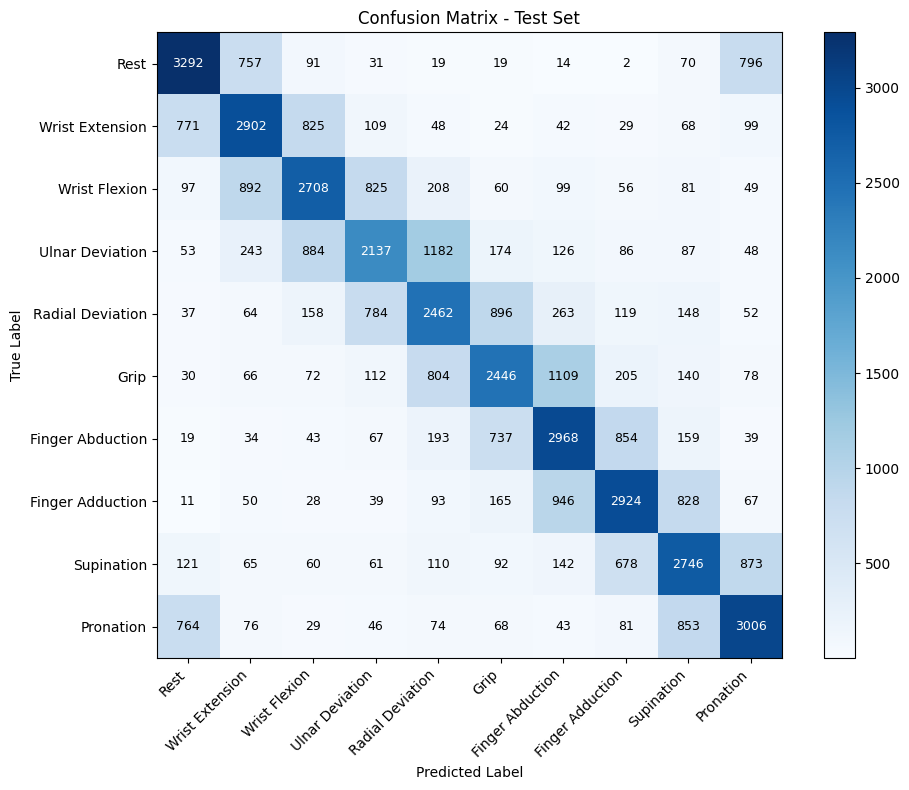

In [15]:
import numpy as np
import matplotlib.pyplot as plt

class_names = [
    "Rest",
    "Wrist Extension",
    "Wrist Flexion",
    "Ulnar Deviation",
    "Radial Deviation",
    "Grip",
    "Finger Abduction",
    "Finger Adduction",
    "Supination",
    "Pronation",
]

model.eval()
all_preds = []
all_targets = []

with torch.no_grad():
    for batch_X, batch_y in test_loader:
        batch_X = batch_X.to(device)
        outputs = model(batch_X)
        preds = torch.argmax(outputs, dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_targets.extend(batch_y.numpy())

num_classes = NUM_CLASSES
cm = np.zeros((num_classes, num_classes), dtype=np.int64)
for true_label, pred_label in zip(all_targets, all_preds):
    cm[true_label, pred_label] += 1

plt.figure(figsize=(10, 8))
plt.imshow(cm, interpolation="nearest", cmap=plt.cm.Blues)
plt.title("Confusion Matrix - Test Set")
plt.colorbar()

indices = np.arange(num_classes)
plt.xticks(indices, class_names, rotation=45, ha="right")
plt.yticks(indices, class_names)

threshold = cm.max() / 2.0 if cm.max() > 0 else 0
for i in range(num_classes):
    for j in range(num_classes):
        plt.text(
            j,
            i,
            format(cm[i, j], "d"),
            ha="center",
            va="center",
            color="white" if cm[i, j] > threshold else "black",
            fontsize=9,
        )

plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.show()
